**Importing Dataset**

In [ ]:
import os
import kagglehub

path = kagglehub.dataset_download("puneet6060/intel-image-classification")
print("Path to dataset files:", path)
EXPECTED = {'buildings','forest','glacier','mountain','sea','street'}

def class_root(base, split_name):

    def subdirs(p):
        return sorted([d for d in os.listdir(p) if os.path.isdir(os.path.join(p,d))])

    if set(subdirs(base)) == EXPECTED:
        return base

    nested = os.path.join(base, split_name)
    if os.path.isdir(nested) and set(subdirs(nested)) == EXPECTED:
        return nested
    raise AssertionError(f"Could not find class folders under {base} (or {nested}).")

TRAIN_DIR = class_root(os.path.join(path, "seg_train"), "seg_train")
TEST_DIR  = class_root(os.path.join(path, "seg_test"),  "seg_test")

print("Resolved TRAIN_DIR ->", TRAIN_DIR)
print("Resolved TEST_DIR  ->", TEST_DIR)
print("Train classes:", sorted(os.listdir(TRAIN_DIR)))
print("Test  classes:", sorted(os.listdir(TEST_DIR)))

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Path to dataset files: /kaggle/input/intel-image-classification
Resolved TRAIN_DIR -> /kaggle/input/intel-image-classification/seg_train/seg_train
Resolved TEST_DIR  -> /kaggle/input/intel-image-classification/seg_test/seg_test
Train classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Test  classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


**Train and Test Data**

In [ ]:
import tensorflow as tf

IMG_SIZE = (150,150)
BATCH    = 32
SEED     = 42

print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.1, subset="training", seed=SEED,
    image_size=IMG_SIZE, batch_size=BATCH
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.1, subset="validation", seed=SEED,
    image_size=IMG_SIZE, batch_size=BATCH
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, shuffle=False, image_size=IMG_SIZE, batch_size=BATCH
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("class_names:", class_names)
# performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

TF: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Found 14034 files belonging to 6 classes.
Using 12631 files for training.
Found 14034 files belonging to 6 classes.
Using 1403 files for validation.
Found 3000 files belonging to 6 classes.
class_names: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [ ]:
from tensorflow.keras import layers, models

tf.keras.backend.clear_session()

model = models.Sequential([
    layers.Conv2D(32, 3, activation='relu', padding='same', input_shape=IMG_SIZE+(3,)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',   # integer labels from tf.data
              metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Train**

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

EPOCHS = 6

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=2, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1, min_lr=1e-5, verbose=1),
]


history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks, verbose=1)

Epoch 1/6
395/395 ━━━━━━━━━━━━━━━━━━━━ 53s 117ms/step - accuracy: 0.3657 - loss: 20.9362 - val_accuracy: 0.4890 - val_loss: 1.2573 - learning_rate: 0.0010
Epoch 2/6
395/395 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - accuracy: 0.5290 - loss: 1.1950 - val_accuracy: 0.5852 - val_loss: 1.0556 - learning_rate: 0.0010
Epoch 3/6
395/395 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.5945 - loss: 1.0503 - val_accuracy: 0.6607 - val_loss: 0.8628 - learning_rate: 0.0010
Epoch 4/6
395/395 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.6730 - loss: 0.8788 - val_accuracy: 0.7099 - val_loss: 0.7789 - learning_rate: 0.0010
Epoch 5/6
395/395 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.7342 - loss: 0.7211 - val_accuracy: 0.7363 - val_loss: 0.7518 - learning_rate: 0.0010
Epoch 6/6
394/395 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7871 - loss: 0.5964
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
395/395 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.7871 - loss: 0

**Evaluate**

In [ ]:
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\nTest Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 139ms/step - accuracy: 0.7478 - loss: 0.7233

Test Accuracy: 0.7167 | Test Loss: 0.7805


**Matrix & Report**

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step

Classification Report:

              precision    recall  f1-score   support

   buildings     0.6455    0.7460    0.6921       437
      forest     0.9350    0.8502    0.8906       474
     glacier     0.6996    0.6908    0.6952       553
    mountain     0.6594    0.6933    0.6760       525
         sea     0.6598    0.5667    0.6097       510
      street     0.7311    0.7705    0.7502       501

    accuracy                         0.7167      3000
   macro avg     0.7218    0.7196    0.7190      3000
weighted avg     0.7204    0.7167    0.7169      3000



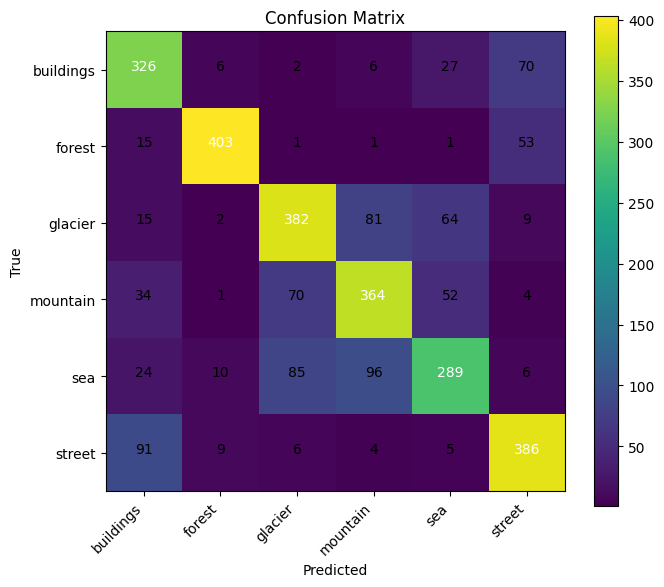

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

probs = model.predict(test_ds, verbose=1)
y_pred = probs.argmax(axis=1)

y_true = np.concatenate([y for _, y in test_ds.unbatch().batch(1024)], axis=0)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7,6))
plt.imshow(cm, interpolation='nearest')
plt.title('Confusion Matrix'); plt.colorbar()
ticks = np.arange(len(class_names))
plt.xticks(ticks, class_names, rotation=45, ha='right'); plt.yticks(ticks, class_names)
thresh = cm.max()/2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center',
                 color='white' if cm[i, j] > thresh else 'black')
plt.ylabel('True'); plt.xlabel('Predicted'); plt.tight_layout(); plt.show()

**Finding New Images**

In [ ]:
from google.colab import files
uploaded = files.upload()  # choose 2-6 .jpg files
!ls

Saving buildings.jpg to buildings.jpg
Saving forest.jpg to forest.jpg
Saving glacier.jpg to glacier.jpg
Saving mountain.jpg to mountain.jpg
Saving sea.jpg to sea.jpg
Saving street.jpg to street.jpg
buildings.jpg  glacier.jpg   sample_data  street.jpg
forest.jpg     mountain.jpg  sea.jpg



🔍 Predicting uploaded images...



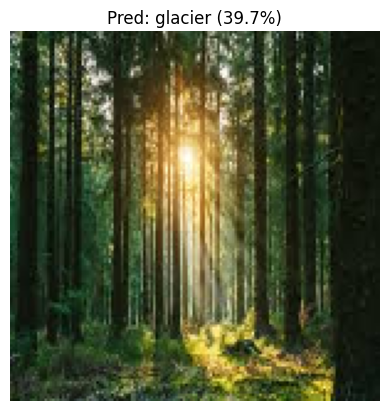


🧾 forest.jpg
  glacier   : 39.70%
  forest    : 21.89%
  mountain  : 15.59%


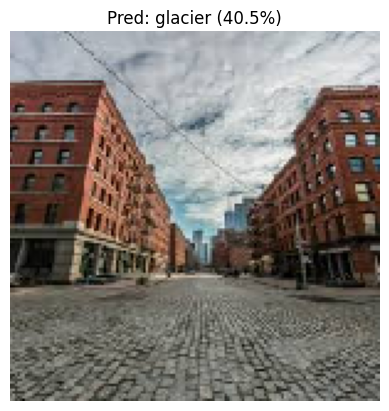


🧾 street.jpg
  glacier   : 40.50%
  forest    : 20.42%
  mountain  : 15.72%


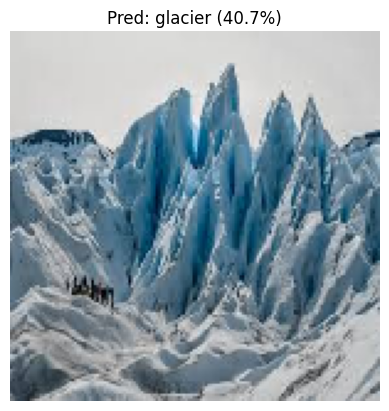


🧾 glacier.jpg
  glacier   : 40.65%
  forest    : 20.15%
  mountain  : 15.88%


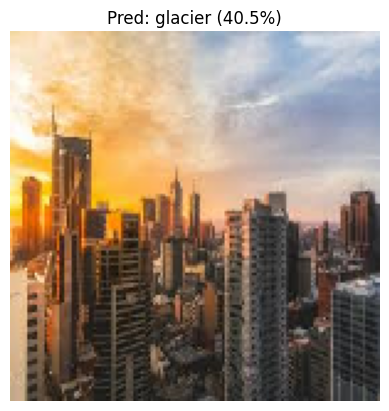


🧾 buildings.jpg
  glacier   : 40.52%
  forest    : 20.24%
  mountain  : 15.80%


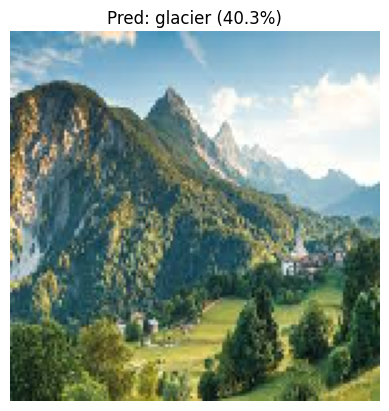


🧾 mountain.jpg
  glacier   : 40.34%
  forest    : 20.76%
  mountain  : 15.84%


In [ ]:
import numpy as np, matplotlib.pyplot as plt, heapq, glob

def predict_google_image(path, model, class_names, img_size=(150,150)):
    img = tf.keras.utils.load_img(path, target_size=img_size)
    arr = tf.keras.utils.img_to_array(img).astype("float32") / 255.0
    pred = model.predict(np.expand_dims(arr, axis=0), verbose=0)[0]
    top3 = heapq.nlargest(3, range(len(pred)), key=lambda i: pred[i])

    plt.imshow(img)
    plt.axis('off')
    title = f"Pred: {class_names[top3[0]]} ({pred[top3[0]]*100:.1f}%)"
    plt.title(title, fontsize=12)
    plt.show()

    print(f"\n🧾 {path}")
    for i in top3:
        print(f"  {class_names[i]:<10}: {pred[i]*100:.2f}%")

# Predict all uploaded images automatically
files = [f for f in glob.glob("*.jpg") + glob.glob("*.png")]
print("\n🔍 Predicting uploaded images...\n")
for f in files:
    predict_google_image(f, model, class_names, IMG_SIZE)


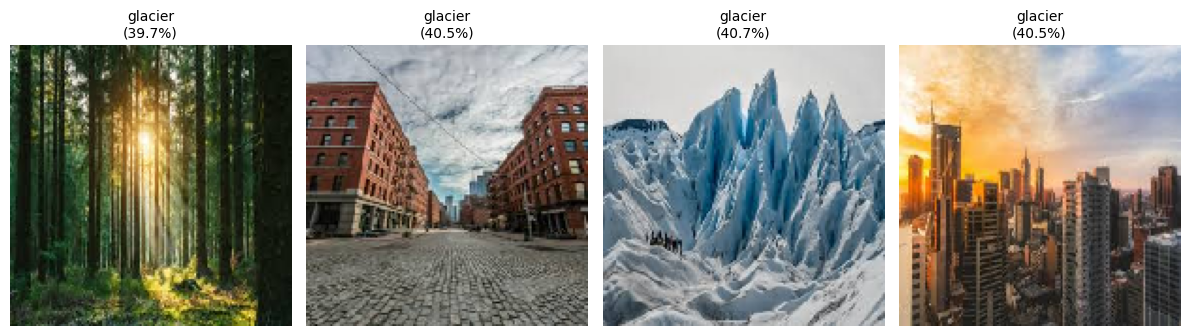

In [ ]:
plt.figure(figsize=(12,6))
for i, f in enumerate(files[:4]):
    img = tf.keras.utils.load_img(f, target_size=IMG_SIZE)
    arr = tf.keras.utils.img_to_array(img).astype("float32") / 255.0
    pred = model.predict(np.expand_dims(arr, axis=0), verbose=0)[0]
    idx = np.argmax(pred)
    plt.subplot(1,4,i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{class_names[idx]}\n({pred[idx]*100:.1f}%)", fontsize=10)
plt.tight_layout()
plt.show()